Import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
#df = pd.read_csv(r'/content/drive/MyDrive/datasets/dataset.csv')
df = pd.read_csv('dataset.csv')
df.head()

,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1


Analyze the dataset

In [ ]:
print("="*15,"Info","="*15)
print(df.info())

print("="*15,"Shape","="*15)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("="*10,"Data Types","="*10)
print(df.dtypes)

print("="*10,"Numerical Stats","="*10)
print(df.describe())

print("="*35)

=============== Info ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB
None
=============== Shape ===============
Rows: 766, Columns: 8
========== Data Types ==========
f1        object
f2        object
f3         int64
f4        object
f5        object
f6        object
f7        object
target     int64
dtype: object
========== Numerical Stats ==========
               f3      target
count  766.000000  766.000000
mean    69.118799    0.349869
std     19.376901    0.477240
min      0.000000    0.000000
25%     62.5

Handle invalid character entries

In [ ]:
df_cleaned = df.copy()

for col in df.columns:

    if df[col].dtype == 'object':
        unique_vals = df[col].unique()

        #regex for alphanumeric values
        invalid_vals = [v for v in unique_vals if not re.match(r'^[0-9a-zA-Z\.\-]*$', str(v))]

        if invalid_vals:
            print("Invalid values found: ")
        else:
            print("No invalid characters found.")

    else:

        col_str = df[col].astype(str)
        col_no_dot = col_str.str.replace('.', '', 1)
        is_digit = col_no_dot.str.isdigit()
        invalid_numeric = df[~is_digit]


        if not invalid_numeric.empty:
            print("Non-numeric values present in numeric column.")
            print(invalid_numeric.head())
        else:
            print("All numeric values are valid.")

    print("-" * 35)

    #Make sure the numerical columns do not include any random characters like '@,$',etc so conversion is more meaningful.
    #No invalid entries found, safe for conversion

No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
All numeric values are valid.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
All numeric values are valid.
-----------------------------------


In [ ]:
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')  # turn invalids into NaN
    print("NaNs in column",col, df_cleaned[col].isna().sum())
    median_val = df_cleaned[col].median()
    df_cleaned.fillna({col:median_val}, inplace=True)

print("All invalid entries handled successfully!")
print(df_cleaned.info())
print(df_cleaned.head())

# Convert the non-numeric columns to numeric and turn invalid entries into NaN, then we fill these NaN values with median of that column
# We also print the number of NaN values on each column and in this dataset. The fact that dataset contains no invalid
# entries(last step) supports the absence of NaNs also.

NaNs in column f1 1
NaNs in column f2 1
NaNs in column f3 0
NaNs in column f4 1
NaNs in column f5 1
NaNs in column f6 1
NaNs in column f7 1
NaNs in column target 0
All invalid entries handled successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    float64
 1   f2      766 non-null    float64
 2   f3      766 non-null    int64  
 3   f4      766 non-null    float64
 4   f5      766 non-null    float64
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.0 KB
None
    f1     f2  f3    f4     f5    f6     f7  target
0  6.0  148.0  72  35.0    0.0  33.6  0.627       1
1  1.0   85.0  66  29.0    0.0  26.6  0.351       0
2  8.0  183.0  64   0.0    0.0  23.3  0.672       1
3  1.0   89.0  66  23.0   94.0  28.1  0.167       0
4  0

4. Data Visulisation

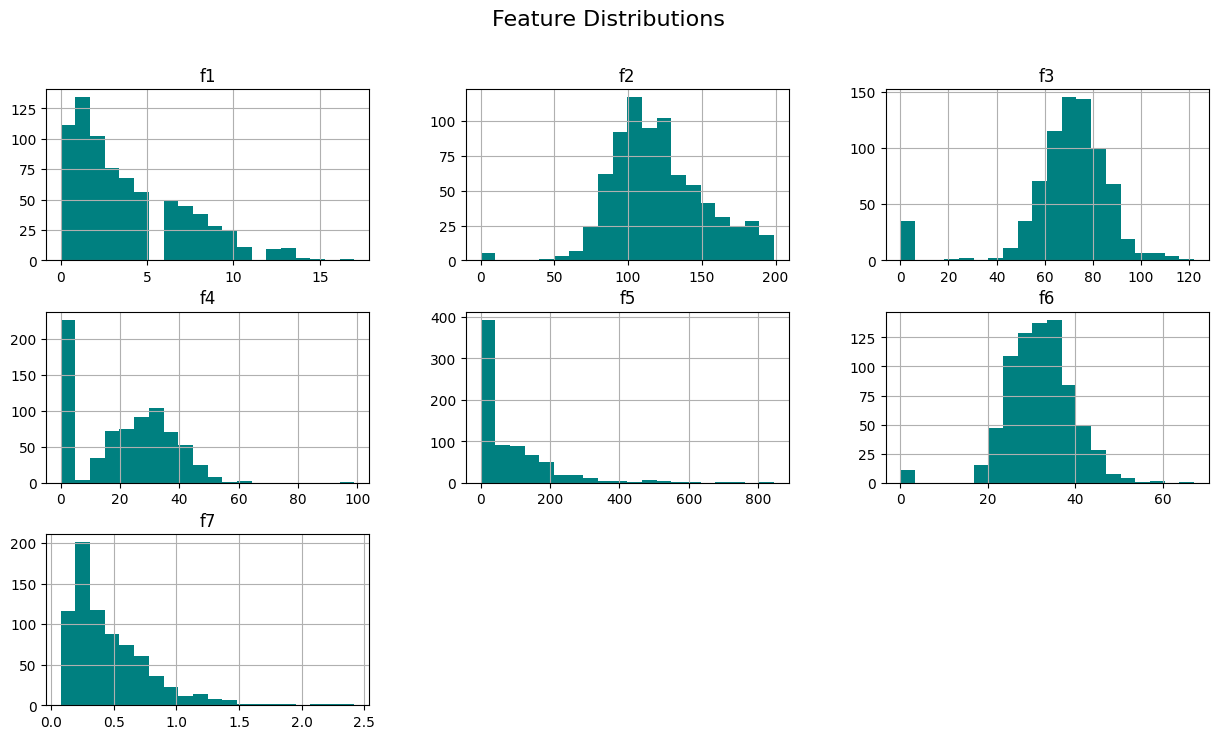

In [ ]:
df_cleaned[['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']].hist(bins=20, figsize=(15, 8), color="teal")
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

# Representation of each input column values on a histogram. Shows how the values are distributed. From the result, columns 'f3','f4'
# and'f6' resemble the normal distribuition curve.


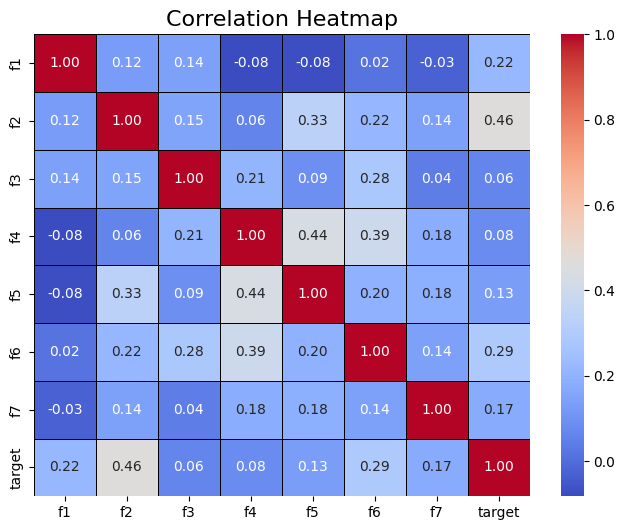

In [ ]:

plt.figure(figsize=(8,6))
corr = df_cleaned.astype(float).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f",linecolor='black', linewidths=0.7)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


# The graph below shows the correlation between feature inputs and target column with each other. For this, first we have to calculate
# the correlation matrix and then represent it using heatmap from seaborn library. We can observe from the result that correlation between
# target and f2 is highest (0.46) which means it must be an important feature to predict target. f3 and the target has lowest correlation
# value (0.06) which means it contributes very less to target variable.

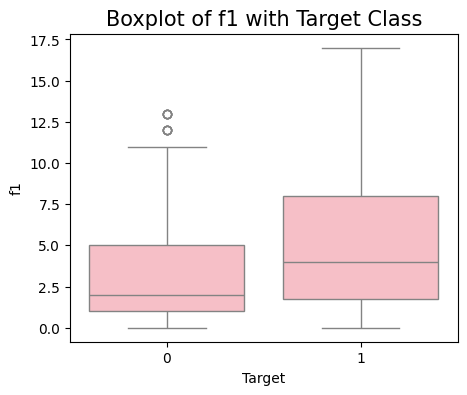

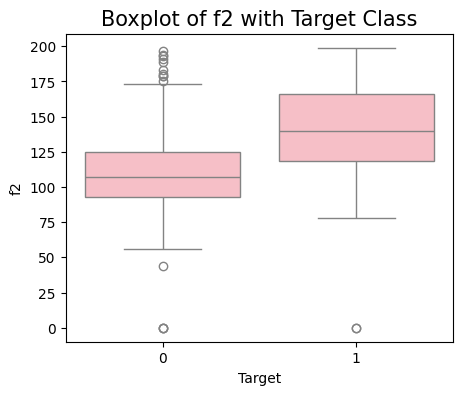

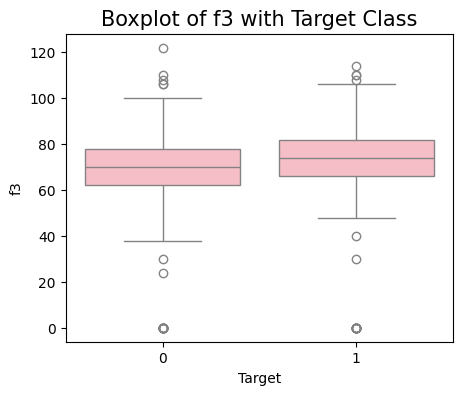

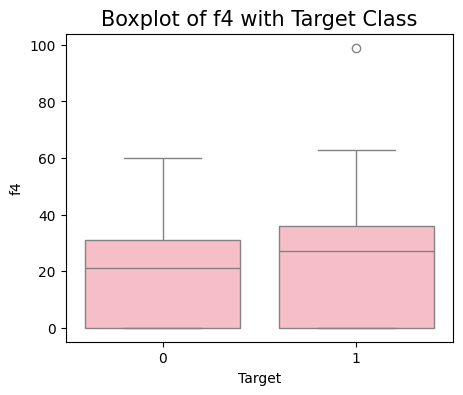

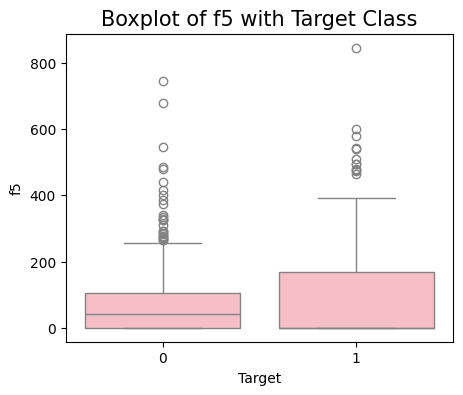

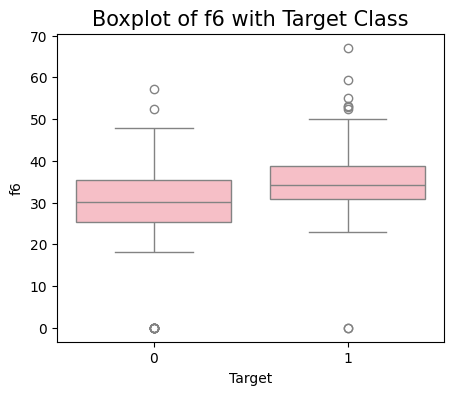

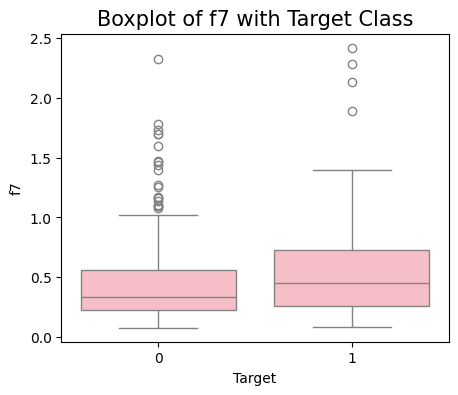

In [ ]:
for col in df_cleaned.columns:
    if col == 'target':  # skip target column
        continue

    plt.figure(figsize=(5,4))
    sns.boxplot(x='target', y=col, data=df_cleaned.astype({col: float}), color = "lightpink")
    plt.title(f'Boxplot of {col} with Target Class', fontsize=15)
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.show()

    # Here we represent box plot of each column with target values (0 and 1). This will help us to identify important trends such as if
    # the value of target is 0, the value of feature input lets say f3 is higher or lower then when the value of target is 1. We have
    # created this plot for each column which will help us identify such relations in each input column with respect to target variable.
    # Additionally, we can visualise the outliers in each input column.


Preprocessing Using Standard Scaler

In [ ]:
import torch

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

print(f" Type of dataset Before: \n {df_cleaned.info()}")

#Apply standard scaling
scaler = StandardScaler()

x_scaled = scaler.fit_transform(df_cleaned.drop('target', axis=1).values)
x_tensorData = torch.tensor(x_scaled, dtype=torch.float32)
y_tensorData = torch.tensor(df_cleaned['target'].values, dtype=torch.long)

print(f"After converting to tensor type (Features): \n{x_tensorData}")

print(f" Feature Tensor type: \n{x_tensorData.dtype}")

print(f" After converting to tensor type (Target): \n{y_tensorData}")

print(f" Target Tensor type: \n{y_tensorData.dtype}")

print(f"\n Check class counts:")
print(f"Positive class: {torch.sum(y_tensorData == 1).item()}")
print(f"Negative class: {torch.sum(y_tensorData == 0).item()}")

#Found imbalance with negatives being 498 and postive less
X_np = x_tensorData.numpy()
y_np = y_tensorData.numpy()

# Apply RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled_np, y_resampled_np = ros.fit_resample(X_np, y_np)

# Converting back to tensors
X_resampled = torch.tensor(X_resampled_np, dtype=torch.float32)
y_resampled = torch.tensor(y_resampled_np, dtype=torch.long)

print(f"\n After RandomOverSampler:")
print(f"Positive class: {torch.sum(y_resampled == 1).item()}")
print(f"Negative class: {torch.sum(y_resampled == 0).item()}")

#Now we have datasets where target is equally distributed


#In our data set before preprocessing we had converted all categorical colums to numerical colums
#and based on that we could apply either standardscaling or normalization. We have choosen standarscaling as
#we are planning to take the standard deviation and its helps fit the data, Also we have handled imbalance data
#however it was optional , since we compared and checked we could see major distribution towards negative classes and hence
#applied randomoversampler

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    float64
 1   f2      766 non-null    float64
 2   f3      766 non-null    int64  
 3   f4      766 non-null    float64
 4   f5      766 non-null    float64
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.0 KB
 Type of dataset Before: 
 None
After converting to tensor type (Features): 
tensor([[ 0.6385,  0.8492,  0.1488,  ..., -0.6945,  0.2031,  0.4681],
        [-0.8454, -1.1253, -0.1611,  ..., -0.6945, -0.6844, -0.3654],
        [ 1.2321,  1.9462, -0.2643,  ..., -0.6945, -1.1027,  0.6040],
        ...,
        [-0.5486,  0.0343,  0.0455,  ..., -0.3821,  0.6088, -0.3986],
        [-0.2518,  0.0030,  0.1488,  ...,  0.2774, -0.7351, -0.6855],
        [-0.8454,  0.1597, -0.4709,

In [ ]:
import random

seed_value = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(seed_value)

Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

#Splitting the intial data into train and test
X_main, X_test, y_main, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=seed_value,stratify=y_resampled)


print(f"Shape of X_main: {X_main.shape}")
print(f"Shape of y_main: {y_main.shape}")

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

#Now splitting training data again into validation

X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.2, random_state=seed_value,stratify=y_main)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")


import sklearn
print(sklearn.__version__)


Shape of X_main: torch.Size([796, 7])
Shape of y_main: torch.Size([796])
Shape of X_test: torch.Size([200, 7])
Shape of y_test: torch.Size([200])
Shape of X_train: torch.Size([636, 7])
Shape of y_train: torch.Size([636])
Shape of X_val: torch.Size([160, 7])
Shape of y_val: torch.Size([160])
1.6.1


 Defining the Neural Network


In [ ]:
!pip install torchinfo


In [ ]:
import torch
import torch.nn as nn
from torchinfo import summary

class NeuralNet(nn.Module):
    def __init__(self, input_dim=7):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        #self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        #x = self.output(x)  # no sigmoid here!
        x = self.sigmoid(self.output(x))  # binary classification output
        return x

model = NeuralNet(input_dim=7)

print(model)

summary(model, input_size=(1, 7))

#There are total 7 input neurons because there are 7 input features and 1 output neuron with value either 0 or 1,
#which reflects our target. Activation function in Hidden layers is relu whereas in ouput layer, it is Sigmoid
#We have 2 hidden layers (fc1: 7->128 neurons and fc2 128->64). We have implemented dropout of rate 0.5%.


NeuralNet(
  (fc1): Linear(in_features=7, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.5, inplace=False)
)


Layer (type:depth-idx)                   Output Shape              Param #
NeuralNet                                [1, 1]                    --
├─Linear: 1-1                            [1, 128]                  1,024
├─ReLU: 1-2                              [1, 128]                  --
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 64]                   8,256
├─ReLU: 1-5                              [1, 64]                   --
├─Dropout: 1-6                           [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
├─Sigmoid: 1-8                           [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04

Training the neural network

In [ ]:
import torch.nn as nn
import torch.optim as optim

#lossFunction = nn.BCEWithLogitsLoss()
lossFunction = nn.BCELoss()
print('Loss function : ',lossFunction)


#pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
#lossFunction = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

optimiser = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

#optimiser = torch.optim.Adam(model.parameters(), lr=0.0001,weight_decay=1e-5)
print('Optimiser : ',optimiser)


Loss function :  BCELoss()
Optimiser :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)


In [ ]:

import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

Path = "a2_part1_weights_rajagop6_dikshant"
best_model_score = float('inf')

numberOfEpochs = 200

batchSize = 32


batchToProcess = (len(X_train)+batchSize-1) // batchSize
#Above includes all the features present in the batch so that none gets dropped


train_loss_list = []
val_loss_list = []
test_loss_list = []

start_time = time.time()
print(f"Batch to process at a go: {batchToProcess}")


train_acc_list = []
val_acc_list = []
test_acc_list = []

g = torch.Generator()
g.manual_seed(seed_value)

for epoch in range(numberOfEpochs):
  epoch_train_loss = 0.0
  perm = torch.randperm(X_train.size(0),generator=g)
  X_train = X_train[perm]
  #print('Suffling X : ',X_train)
  y_train = y_train[perm]
  #print('Suffling Y: ',y_train)
  for i in range(batchToProcess):
    X_train_batch = X_train[i*batchSize:(i*batchSize)+batchSize]
    y_train_batch = y_train[i*batchSize:(i*batchSize)+batchSize]


    outputs = model(X_train_batch)
    loss = lossFunction(outputs.squeeze(),y_train_batch.float())
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss += loss.item()

    # print(f"Epoch at current step:{epoch+1} and loss: {loss.item()}")

  avg_train_loss = epoch_train_loss / batchToProcess
  train_loss_list.append(avg_train_loss)  # append once per epoch
  print(f"Epoch {epoch+1} Average Training Loss: {avg_train_loss}")

  #calculate values for validation dataset
  model.eval()
  with torch.no_grad():
    outputs_val = model(X_val)
    loss_val = lossFunction(outputs_val.squeeze(), y_val.float())
    val_loss_list.append(loss_val.item())
    print(f"Validation loss at epoch: {epoch+1} and loss: {loss_val.item()}")


    outputs_test = model(X_test)
    loss_test = lossFunction(outputs_test.squeeze(), y_test.float())
    test_loss_list.append(loss_test.item())



    train_outputs = model(X_train)
    train_probs = torch.sigmoid(train_outputs.squeeze())
    train_preds = (train_probs >= 0.6).float()
    train_acc = accuracy_score(y_train.cpu().numpy(), train_preds.cpu().numpy())

    val_probs = torch.sigmoid(outputs_val.squeeze())
    val_preds = (val_probs >= 0.6).float()
    val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())

    test_outputs = model(X_test)
    test_probs = torch.sigmoid(test_outputs.squeeze())
    test_preds = (test_probs >= 0.6).float()
    test_acc = accuracy_score(y_test.cpu().numpy(), test_preds.cpu().numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)


    print(f"Epoch {epoch+1}/{numberOfEpochs} | "
    f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")


    if loss_val.item() < best_model_score:
      best_model_score = loss_val.item()
      torch.save(model.state_dict(), Path)
      print(f"Model saved at epoch: {epoch+1} and loss: {best_model_score}")

  model.train() #Shifting back to original so that it runs properly for other epochs

end_time = time.time()
print(f"Ttime taken: {end_time - start_time} seconds")


Batch to process at a go: 20


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

Evaluate the performance of the model on the testing data

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_probs = torch.sigmoid(y_pred_logits.squeeze())
    y_pred_labels = (y_pred_probs >= 0.6).float()

y_true = y_test.cpu().numpy()
y_pred_labels_np = y_pred_labels.cpu().numpy()
print(y_pred_labels_np)



accuracy = accuracy_score(y_true, y_pred_labels_np)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_labels_np, average='binary', zero_division=0
)



In [ ]:
print("=== Model Evaluation on Test Data ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Visualize

In [ ]:
epochs = np.arange(1, len(train_acc_list) + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs, train_acc_list, label='Training Accuracy', color='blue')
plt.plot(epochs, val_acc_list, label='Validation Accuracy', color='orange')
plt.plot(epochs, test_acc_list, label='Test Accuracy', color='green')

plt.title('Training vs Validation vs Test Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

#We can observe that the accuracy increases exponentially in the starting epochs but becomes almost stable in the
#range 50-100. This is true for all three (test, train and validation) accuracies.  Hence, early stopping might be effective
#in this case

In [ ]:

plt.figure(figsize=(10,6))
plt.plot(epochs, train_loss_list, label='Training Loss', color='blue')
plt.plot(epochs, val_loss_list, label='Validation Loss', color='orange')
plt.plot(epochs, test_loss_list, label='Test Loss', color='green', linestyle='--')
plt.title('Training vs Validation vs Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#We can observe that the loss decreases rapidly in the initial epochs but test and train loss become stable after approximately 75 epochs.
#Validation loss also does not decrease significantly after 100-125 epochs.

In [ ]:
from sklearn.metrics import confusion_matrix



y_true = y_test.cpu().numpy() if torch.is_tensor(y_test) else y_test
y_pred = test_preds.cpu().numpy() if torch.is_tensor(test_preds) else test_preds

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
y_true = y_test.cpu().numpy() if torch.is_tensor(y_test) else y_test

y_scores = test_probs.cpu().numpy() if torch.is_tensor(test_probs) else test_probs.detach().numpy()




from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

print(f"AUC Score: {roc_auc:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate ')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


References:

1.https://seaborn.pydata.org/generated/seaborn.heatmap.html

2.https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html
3.https://docs.pytorch.org/tutorials/beginner/introyt/introyt_index.html
4. https://towardsdatascience.com/stratified-sampling-you-may-have-been-splitting-your-dataset-all-wrong-8cfdd0d32502/
5. https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html


Contribuition Table

### PART 2:

Tune Hyperparameters

In [ ]:
#Model from Step 1

class NeuralNet(nn.Module):
    def __init__(self, input_dim=7):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        #x = self.output(x)  # no sigmoid here!
        x = self.sigmoid(self.output(x))  # binary classification output
        return x

model = NeuralNet(input_dim=7)

print(model)

summary(model, input_size=(1, 7))




In [ ]:

#lossFunction = nn.BCEWithLogitsLoss()
lossFunction = nn.BCELoss()
print('Loss function : ',lossFunction)


#pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
#lossFunction = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

lrs = [0.001,0.0001,0.01]
for lr in lrs:

  optimiser = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

#optimiser = torch.optim.Adam(model.parameters(), lr=0.0001,weight_decay=1e-5)
print('Optimiser : ',optimiser)


Loss function :  BCELoss()


NameError: name 'optim' is not defined

In [ ]:
import copy

learning_rates = [1e-2, 1e-3, 1e-4]
results = {}

initial_state = copy.deepcopy(model.state_dict())

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    model.load_state_dict(initial_state)

    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    train_loss_list = []
    val_loss_list = []
    test_loss_list = []
    train_acc_list = []
    val_acc_list = []
    test_acc_list = []

    best_model_score = float('inf')

    for epoch in range(numberOfEpochs):
        epoch_train_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        X_train = X_train[perm]
        y_train = y_train[perm]

        for i in range(batchToProcess):
            X_train_batch = X_train[i*batchSize:(i*batchSize)+batchSize]
            y_train_batch = y_train[i*batchSize:(i*batchSize)+batchSize]

            outputs = model(X_train_batch)
            loss = lossFunction(outputs.squeeze(), y_train_batch.float())
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / batchToProcess
        train_loss_list.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            outputs_val = model(X_val)
            loss_val = lossFunction(outputs_val.squeeze(), y_val.float())
            val_loss_list.append(loss_val.item())

            outputs_test = model(X_test)
            loss_test = lossFunction(outputs_test.squeeze(), y_test.float())
            test_loss_list.append(loss_test.item())

            # Accuracy calculations
            train_outputs = model(X_train)
            train_probs = torch.sigmoid(train_outputs.squeeze())
            train_preds = (train_probs >= 0.6).float()
            train_acc = accuracy_score(y_train.cpu().numpy(), train_preds.cpu().numpy())

            val_probs = torch.sigmoid(outputs_val.squeeze())
            val_preds = (val_probs >= 0.6).float()
            val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())

            test_probs = torch.sigmoid(outputs_test.squeeze())
            test_preds = (test_probs >= 0.6).float()
            test_acc = accuracy_score(y_test.cpu().numpy(), test_preds.cpu().numpy())

            train_acc_list.append(train_acc)
            val_acc_list.append(val_acc)
            test_acc_list.append(test_acc)

            print(f"Epoch {epoch+1}/{numberOfEpochs} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

            # Save best model per lr
            # if loss_val.item() < best_model_score:
            #     best_model_score = loss_val.item()
            #     torch.save(model.state_dict(), f"{Path}_lr{lr}.pt")
            #     print(f"Model saved for lr={lr} at epoch {epoch+1}, val loss={best_model_score}")

        model.train()

    results[lr] = {
        'train_loss': train_loss_list,
        'val_loss': val_loss_list,
        'test_loss': test_loss_list,
        'train_acc': train_acc_list,
        'val_acc': val_acc_list,
        'test_acc': test_acc_list
    }


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_probs = torch.sigmoid(y_pred_logits.squeeze())
    y_pred_labels = (y_pred_probs >= 0.6).float()

y_true = y_test.cpu().numpy()
y_pred_labels_np = y_pred_labels.cpu().numpy()



accuracy = accuracy_score(y_true, y_pred_labels_np)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_labels_np, average='binary', zero_division=0
)



In [ ]:
#Results for different learning rate values
for lr, metrics in results.items():
    print(f"\nLearning rate: {lr}")
    print(f"  Final Train Loss: {metrics['train_loss'][-1]:.4f}")
    print(f"  Final Val Loss:   {metrics['val_loss'][-1]:.4f}")
    print(f"  Final Test Loss:  {metrics['test_loss'][-1]:.4f}")
    print(f"  Final Train Acc:  {metrics['train_acc'][-1]:.4f}")
    print(f"  Final Val Acc:    {metrics['val_acc'][-1]:.4f}")
    print(f"  Final Test Acc:   {metrics['test_acc'][-1]:.4f}")


Now with different layers

In [ ]:
class DynamicNet(nn.Module):
    def __init__(self, input_layer, hidden_layer, output_dim):
        super(DynamicNet, self).__init__()
        layers = []
        prev_dim = input_layer
        for h_dim in hidden_layer:
            layers.append(nn.Linear(prev_dim, h_dim))
            prev_dim = h_dim
        self.hidden_layers = nn.ModuleList(layers)
        self.output = nn.Linear(prev_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        return torch.sigmoid(self.output(x))


model = DynamicNet(input_layer=7, hidden_layer=[256, 64, 32], output_dim=1)
model2 = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
model3 = DynamicNet(input_layer=7, hidden_layer=[128, 64], output_dim=1)
print('Model 1')
print(summary(model, input_size=(1, 7)))
print('\n Model 2')
print(summary(model2, input_size=(1, 7)))
print('\n Model 3')
print(summary(model3, input_size=(1, 7)))


In [ ]:
import torch.nn as nn
import torch.optim as optim

#lossFunction = nn.BCEWithLogitsLoss()
lossFunction = nn.BCELoss()
print('Loss function : ',lossFunction)


In [ ]:
import copy
import torch
from sklearn.metrics import accuracy_score

# Define your models here
models = {
    "Model 1": model,
    "Model 2": model2,
    "Model 3": model3
}

results = {}  # to store train/val/test losses & acc per model

for model_name, model in models.items():
    print(f"\n--------Training {model_name}-----------")

    # Save a copy of initial model weights so you can re-initialize if needed
    initial_state = copy.deepcopy(model.state_dict())

    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)  # single LR used for all models
    best_model_score = float('inf')

    train_loss_list = []
    val_loss_list = []
    test_loss_list = []
    train_acc_list = []
    val_acc_list = []
    test_acc_list = []

    for epoch in range(numberOfEpochs):
        epoch_train_loss = 0.0

        # Shuffle training data
        perm = torch.randperm(X_train.size(0))
        X_train = X_train[perm]
        y_train = y_train[perm]

        # Mini-batch loop
        for i in range(batchToProcess):
            X_train_batch = X_train[i * batchSize:(i + 1) * batchSize]
            y_train_batch = y_train[i * batchSize:(i + 1) * batchSize]

            outputs = model(X_train_batch)
            loss = lossFunction(outputs.squeeze(), y_train_batch.float())

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / batchToProcess
        train_loss_list.append(avg_train_loss)

        # Validation & testing
        model.eval()
        with torch.no_grad():
            outputs_val = model(X_val)
            loss_val = lossFunction(outputs_val.squeeze(), y_val.float())
            val_loss_list.append(loss_val.item())

            outputs_test = model(X_test)
            loss_test = lossFunction(outputs_test.squeeze(), y_test.float())
            test_loss_list.append(loss_test.item())

            # Accuracy calculations
            train_outputs = model(X_train)
            train_probs = torch.sigmoid(train_outputs.squeeze())
            train_preds = (train_probs >= 0.6).float()
            train_acc = accuracy_score(y_train.cpu().numpy(), train_preds.cpu().numpy())

            val_probs = torch.sigmoid(outputs_val.squeeze())
            val_preds = (val_probs >= 0.6).float()
            val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())

            test_probs = torch.sigmoid(outputs_test.squeeze())
            test_preds = (test_probs >= 0.6).float()
            test_acc = accuracy_score(y_test.cpu().numpy(), test_preds.cpu().numpy())

            train_acc_list.append(train_acc)
            val_acc_list.append(val_acc)
            test_acc_list.append(test_acc)

            print(f"{model_name} | Epoch {epoch+1}/{numberOfEpochs} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

        model.train()

    # Store all results for this model
    results[model_name] = {
        'train_loss': train_loss_list,
        'val_loss': val_loss_list,
        'test_loss': test_loss_list,
        'train_acc': train_acc_list,
        'val_acc': val_acc_list,
        'test_acc': test_acc_list
    }

    print(f"------------- Finished training {model_name}-------------------------")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Dictionary of  trained models
models = {
    "Model 1": model,
    "Model 2 ": model2,
    "Model 3": model3
}

# Dictionary to store results
test_results = {}

# Loop over each model
for model_name, model in models.items():
    model.eval()
    with torch.no_grad():
        y_pred_logits = model(X_test)
        y_pred_probs = torch.sigmoid(y_pred_logits.squeeze())
        y_pred_labels = (y_pred_probs >= 0.6).float()

    # Convert to NumPy for sklearn metrics
    y_true = y_test.cpu().numpy()
    y_pred_labels_np = y_pred_labels.cpu().numpy()

    # Compute metrics
    accuracy = accuracy_score(y_true, y_pred_labels_np)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_labels_np, average='binary', zero_division=0
    )

    # Store results
    test_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\n---- {model_name} Evaluation on Test Data ----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")



3rd Hyperparameter - Batch size

In [ ]:
#Taking the model from the step 1 and 2 as base
#Model 2
#Learning rate as 0.001

class DynamicNet(nn.Module):
    def __init__(self, input_layer, hidden_layer, output_dim):
        super(DynamicNet, self).__init__()
        layers = []
        prev_dim = input_layer
        for h_dim in hidden_layer:
            layers.append(nn.Linear(prev_dim, h_dim))
            prev_dim = h_dim
        self.hidden_layers = nn.ModuleList(layers)
        self.output = nn.Linear(prev_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        return torch.sigmoid(self.output(x))


'''
model2 = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
print('\n Model 2')
print(summary(model2, input_size=(1, 7)))
'''

In [ ]:
import torch.nn as nn
import torch.optim as optim

#lossFunction = nn.BCEWithLogitsLoss()
lossFunction = nn.BCELoss()
print('Loss function : ',lossFunction)


In [ ]:
import copy
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

seed = 34
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

numberOfEpochs = 200

# Batch sizes
batchSizes = {
    "batchSize 1": 32,
    "batchSize 2": 35,
    "batchSize 3": 45
}

base_results = {}      # store train/val/test losses & accuracies per model
base_test_results = {} # store final test metrics

# Loop over batch sizes
for batchname, batchsize in batchSizes.items():

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    print(f"\n-------- Training with {batchname} ({batchsize}) --------")

    # Create a new model instance for each batch size
    model2 = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
    optimiser = torch.optim.Adam(model2.parameters(), lr=1e-3)
    lossFunction = nn.BCELoss()

    train_loss_list, val_loss_list, test_loss_list = [], [], []
    train_acc_list, val_acc_list, test_acc_list = [], [], []

    num_batches = (len(X_train) + batchsize - 1) // batchsize

    for epoch in range(numberOfEpochs):
        model2.train()
        epoch_train_loss = 0.0

        # Shuffle training data
        perm = torch.randperm(X_train.size(0))
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]

        # Mini-batch training
        for i in range(num_batches):
            X_batch = X_train_shuffled[i * batchsize:(i + 1) * batchsize]
            y_batch = y_train_shuffled[i * batchsize:(i + 1) * batchsize]

            outputs = model2(X_batch)
            loss = lossFunction(outputs.squeeze(), y_batch.float())

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item()

        train_loss_list.append(epoch_train_loss / num_batches)

        # Validation & test evaluation
        model2.eval()
        with torch.no_grad():
            # Validation
            val_outputs = model2(X_val)
            val_loss = lossFunction(val_outputs.squeeze(), y_val.float()).item()
            val_loss_list.append(val_loss)
            val_preds = (torch.sigmoid(val_outputs.squeeze()) >= 0.6).float()
            val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())
            val_acc_list.append(val_acc)

            # Test
            test_outputs = model2(X_test)
            test_loss = lossFunction(test_outputs.squeeze(), y_test.float()).item()
            test_loss_list.append(test_loss)
            test_preds = (torch.sigmoid(test_outputs.squeeze()) >= 0.6).float()
            test_acc = accuracy_score(y_test.cpu().numpy(), test_preds.cpu().numpy())
            test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}/{numberOfEpochs} | Train Loss: {train_loss_list[-1]:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # Store epoch metrics
    base_results[batchname] = {
        'train_loss': train_loss_list,
        'val_loss': val_loss_list,
        'test_loss': test_loss_list,
        'val_acc': val_acc_list,
        'test_acc': test_acc_list
    }

    # Compute final test metrics
    model2.eval()
    with torch.no_grad():
        y_test_pred_probs = torch.sigmoid(model2(X_test).squeeze())
        y_test_pred_labels = (y_test_pred_probs >= 0.6).float()
        y_true = y_test.cpu().numpy()
        y_pred_np = y_test_pred_labels.cpu().numpy()

        accuracy = accuracy_score(y_true, y_pred_np)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred_np, average='binary', zero_division=0
        )

    base_test_results[batchname] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\n---- {batchname} Evaluation on Test Data ----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

K-FOLD METHOD

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

numberOfEpochs = 200
batch_size = 45  # fixed batch size
k_folds = 5      # number of folds

results = {}      # store train/val losses & accuracies per fold
test_results = {} # store final test metrics per fold

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    # Split the data
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]

    # Initialize a new model for each fold
    model = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossFunction = nn.BCELoss()

    train_loss_list, val_loss_list = [], []
    val_acc_list = []

    num_batches = (len(X_train_fold) + batch_size - 1) // batch_size

    for epoch in range(numberOfEpochs):
        model.train()
        epoch_train_loss = 0.0

        # Shuffle training data
        perm = torch.randperm(X_train_fold.size(0))
        X_train_shuffled = X_train_fold[perm]
        y_train_shuffled = y_train_fold[perm]


        for i in range(num_batches):
            X_batch = X_train_shuffled[i * batch_size:(i + 1) * batch_size]
            y_batch = y_train_shuffled[i * batch_size:(i + 1) * batch_size]

            outputs = model(X_batch)
            loss = lossFunction(outputs.squeeze(), y_batch.float())

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item()

        train_loss_list.append(epoch_train_loss / num_batches)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_fold)
            val_loss = lossFunction(val_outputs.squeeze(), y_val_fold.float()).item()
            val_loss_list.append(val_loss)
            val_preds = (torch.sigmoid(val_outputs.squeeze()) >= 0.6).float()
            val_acc = accuracy_score(y_val_fold.cpu().numpy(), val_preds.cpu().numpy())
            val_acc_list.append(val_acc)

    # Store values per fold
    results[f"Fold {fold+1}"] = {
        'train_loss': train_loss_list,
        'val_loss': val_loss_list,
        'val_acc': val_acc_list
    }

    # Evaluate on the test set
    model.eval()
    with torch.no_grad():
        y_test_pred_probs = torch.sigmoid(model(X_test).squeeze())
        y_test_pred_labels = (y_test_pred_probs >= 0.6).float()
        y_true = y_test.cpu().numpy()
        y_pred_np = y_test_pred_labels.cpu().numpy()

        accuracy = accuracy_score(y_true, y_pred_np)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred_np, average='binary', zero_division=0
        )

    test_results[f"Fold {fold+1}"] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    # Print results after training for this fold
    print(f"\n----Fold {fold+1} Completed-------")
    print(f"Final Training Loss: {train_loss_list[-1]:.4f}")
    print(f"Final Validation Loss: {val_loss_list[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_list[-1]:.4f}")
    print(f"Test Accuracy : {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall   : {recall:.4f}")
    print(f"Test F1 Score : {f1:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Make a list of losses and thee accuracies
train_loss_all = np.array([results[f]['train_loss'] for f in results])
val_loss_all   = np.array([results[f]['val_loss'] for f in results])
val_acc_all    = np.array([results[f]['val_acc'] for f in results])


# Compute mean across folds
train_loss_mean = np.mean(train_loss_all, axis=0)
#val_loss_mean   = np.mean(val_loss_all, axis=)
val_loss_mean   = np.mean(val_loss_all, axis=0)
val_acc_mean    = np.mean(val_acc_all, axis=0)

# Plot Train & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(train_loss_mean, label='Train Loss')
plt.plot(val_loss_mean, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss (Average Across Folds)')
plt.legend()
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(val_acc_mean, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy (Average Across Folds)')
plt.legend()
plt.show()


Learning rate scheduler

In [ ]:
#Importing the libraries to be on the same side
import copy
import torch
import torch.nn as nn
import numpy as np
import random
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.optim.lr_scheduler import StepLR

#Defining seed to maintain stability in resuls
seed = 34
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

numberOfEpochs = 200
batchsize = 45

results = {}
test_results = {}

print(f"\n-------- Training the Model-------")

model2 = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
optimiser = torch.optim.Adam(model2.parameters(), lr=1e-3)
lossFunction = nn.BCELoss()

#Defining the scheduler
scheduler = StepLR(optimiser, step_size=50, gamma=0.5)

train_loss_list, val_loss_list, test_loss_list = [], [], []
train_acc_list, val_acc_list, test_acc_list = [], [], []

num_batches = (len(X_train) + batchsize - 1) // batchsize

for epoch in range(numberOfEpochs):
    model2.train()
    epoch_train_loss = 0.0
    #Keeping model 2 as it yielded the best result
    perm = torch.randperm(X_train.size(0))
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]

    for i in range(num_batches):
        X_batch = X_train_shuffled[i * batchsize:(i + 1) * batchsize]
        y_batch = y_train_shuffled[i * batchsize:(i + 1) * batchsize]

        outputs = model2(X_batch)
        loss = lossFunction(outputs.squeeze(), y_batch.float())

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_train_loss += loss.item()

    scheduler.step()
    train_loss_list.append(epoch_train_loss / num_batches)

    model2.eval()
    with torch.no_grad():
        val_outputs = model2(X_val)
        val_loss = lossFunction(val_outputs.squeeze(), y_val.float()).item()
        val_loss_list.append(val_loss)
        val_preds = (torch.sigmoid(val_outputs.squeeze()) >= 0.6).float()
        val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())
        val_acc_list.append(val_acc)

        test_outputs = model2(X_test)
        test_loss = lossFunction(test_outputs.squeeze(), y_test.float()).item()
        test_loss_list.append(test_loss)
        test_preds = (torch.sigmoid(test_outputs.squeeze()) >= 0.6).float()
        test_acc = accuracy_score(y_test.cpu().numpy(), test_preds.cpu().numpy())
        test_acc_list.append(test_acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{numberOfEpochs} | LR: {current_lr:.6f} "
              f"| Train Loss: {train_loss_list[-1]:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

#Storing the values
results = {
    'train_loss': train_loss_list,
    'val_loss': val_loss_list,
    'test_loss': test_loss_list,
    'val_acc': val_acc_list,
    'test_acc': test_acc_list
}

model2.eval()
with torch.no_grad():
    y_test_pred_probs = torch.sigmoid(model2(X_test).squeeze())
    y_test_pred_labels = (y_test_pred_probs >= 0.6).float()
    y_true = y_test.cpu().numpy()
    y_pred_np = y_test_pred_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_np)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_np, average='binary', zero_division=0
    )

test_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

print(f"\nEvaluation on Test Data ----")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


In [ ]:
import matplotlib.pyplot as plt

#Loss of train/val/test
plt.figure(figsize=(10,5))
plt.plot(results['train_loss'], label='Train Loss')
plt.plot(results['val_loss'], label='Validation Loss')
plt.plot(results['test_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation & Test Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy of Validation and test datasets
plt.figure(figsize=(10,5))
plt.plot(results['val_acc'], label='Validation Accuracy')
plt.plot(results['test_acc'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation & Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#
print("Final Test Metrics:")
for k, v in test_results.items():
    print(f"{k}: {v:.2f}")


Early Stopping Implementation

In [ ]:

seed = 34
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

numberOfEpochs = 200
batch_size = 32
patience = 40  # early stopping patience


model_early = DynamicNet(input_layer=7, hidden_layer=[64, 32], output_dim=1)
optimiser = torch.optim.Adam(model_early.parameters(), lr=0.001)
lossFunction = nn.BCELoss()

train_loss_list, val_loss_list = [], []
val_acc_list = []

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
best_epoch = 0

num_batches = (len(X_train) + batch_size - 1) // batch_size

for epoch in range(numberOfEpochs):
    model_early.train()
    epoch_train_loss = 0.0


    perm = torch.randperm(X_train.size(0))
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]


    for i in range(num_batches):
        X_batch = X_train_shuffled[i * batch_size:(i + 1) * batch_size]
        y_batch = y_train_shuffled[i * batch_size:(i + 1) * batch_size]

        outputs = model_early(X_batch)
        loss = lossFunction(outputs.squeeze(), y_batch.float())

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Validation
    model_early.eval()
    with torch.no_grad():
        val_outputs = model_early(X_val)
        val_loss = lossFunction(val_outputs.squeeze(), y_val.float()).item()
        val_loss_list.append(val_loss)
        val_preds = (torch.sigmoid(val_outputs.squeeze()) >= 0.6).float()
        val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())
        val_acc_list.append(val_acc)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_early.state_dict().copy()
        best_epoch = epoch
        patience_counter = 0
        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} [BEST]")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best model was at epoch {best_epoch+1} with validation loss: {best_val_loss:.4f}")
            break


model_early.load_state_dict(best_model_state)


print("\nFinal Evaluation on Test Set")
model_early.eval()
with torch.no_grad():
    y_test_pred_probs = torch.sigmoid(model_early(X_test).squeeze())
    y_test_pred_labels = (y_test_pred_probs >= 0.6).float()
    y_true = y_test.cpu().numpy()
    y_pred_np = y_test_pred_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_np)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_np, average='binary', zero_division=0
    )

print(f"Best Model (Epoch {best_epoch+1}):")
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")


In [ ]:
base_batch45 = base_results['batchSize 3']
base_metrics = base_test_results['batchSize 3']

# Get improved model results
improved_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

base_epochs = 200
improved_epochs = best_epoch + 1

 # Compare Test Performance
plt.figure(figsize=(10, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
base_values = [base_metrics[m] for m in metrics]
improved_values = [improved_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x - width/2, base_values, width, label='Base Model', color='blue', alpha=0.7)
bars2 = plt.bar(x + width/2, improved_values, width, label='Improved Model', color='orange', alpha=0.7)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Test Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Compare Training Time
plt.figure(figsize=(8, 5))

bars = plt.bar(['Base Model', 'Improved Model'],
               [base_epochs, improved_epochs],
               color=['blue', 'orange'], alpha=0.7)

plt.ylabel('Epochs')
plt.title('Training Time')
plt.grid(axis='y', alpha=0.3)

plt.text(0, base_epochs + 5, str(base_epochs), ha='center')
plt.text(1, improved_epochs + 5, str(improved_epochs), ha='center')

plt.tight_layout()
plt.show()

# 3. Compare Training Loss
plt.figure(figsize=(10, 5))

plt.plot(base_batch45['train_loss'], label='Base Model', color='blue')
plt.plot(train_loss_list, label='Improved Model', color='orange')
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Stopped Here')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#Hence, we can observe that early stopping did not decrease the accuracy a lot but improved execution
# time significantly.


Batch Normalisation

In [ ]:

# Define model with Batch Normalization
class DynamicNetWithBatchNorm(nn.Module):
    def __init__(self, input_layer, hidden_layer, output_dim):
        super(DynamicNetWithBatchNorm, self).__init__()

        layers = []
        prev_size = input_layer

        for hidden_size in hidden_layer:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))  # Add Batch Normalization
            layers.append(nn.ReLU())
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_dim))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:

numberOfEpochs = 200
batch_size = 45

# Initialize model with Batch Normalization
model = DynamicNetWithBatchNorm(input_layer=7, hidden_layer=[64, 32], output_dim=1)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)


train_loss_list, val_loss_list = [], []
val_acc_list = []

num_batches = (len(X_train) + batch_size - 1) // batch_size


for epoch in range(numberOfEpochs):
    model.train()
    epoch_train_loss = 0.0

    # Shuffle training data
    perm = torch.randperm(X_train.size(0))
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]

    # Mini-batch training
    for i in range(num_batches):
        X_batch = X_train_shuffled[i * batch_size:(i + 1) * batch_size]
        y_batch = y_train_shuffled[i * batch_size:(i + 1) * batch_size]

        outputs = model(X_batch)
        loss = lossFunction(outputs.squeeze(), y_batch.float())

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = lossFunction(val_outputs.squeeze(), y_val.float()).item()
        val_loss_list.append(val_loss)
        val_preds = (val_outputs.squeeze() >= 0.6).float()
        val_acc = accuracy_score(y_val.cpu().numpy(), val_preds.cpu().numpy())
        val_acc_list.append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{numberOfEpochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


print("\nFinal Evaluation on Test Set ")
model.eval()
with torch.no_grad():
    y_test_pred_probs = model(X_test).squeeze()
    y_test_pred_labels = (y_test_pred_probs >= 0.6).float()
    y_true = y_test.cpu().numpy()
    y_pred_np = y_test_pred_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_np)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_np, average='binary', zero_division=0
    )

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")

# Store results
batchnorm_results = {
    'train_loss': train_loss_list,
    'val_loss': val_loss_list,
    'val_acc': val_acc_list
}

batchnorm_test_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

base_batch45 = base_results['batchSize 3']
base_metrics = base_test_results['batchSize 3']

batchnorm_metrics = batchnorm_test_results

base_epochs = 200
batchnorm_epochs = 200

# Compare Test Performance
plt.figure(figsize=(10, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
base_values = [base_metrics[m] for m in metrics]
batchnorm_values = [batchnorm_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x - width/2, base_values, width, label='Base Model', color='blue', alpha=0.7)
bars2 = plt.bar(x + width/2, batchnorm_values, width, label='Batch Normalization', color='green', alpha=0.7)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Test Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Compare Training Loss
plt.figure(figsize=(10, 5))

plt.plot(base_batch45['train_loss'], label='Base Model', color='blue')
plt.plot(batchnorm_results['train_loss'], label='Batch Normalization', color='green')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Compare Validation Accuracy
plt.figure(figsize=(10, 5))

plt.plot(base_batch45['val_acc'], label='Base Model', color='blue')
plt.plot(batchnorm_results['val_acc'], label='Batch Normalization', color='green')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
Path = "a2_part2_weights_rajagop6_dikshant"

torch.save(model_early.state_dict(), Path)


#Hyperparameter being learning rate
| Setup   | Value | Test Accuracy |
|----------|--------|---------------|
| Setup 1  | 1e-2   | 77 |
| Setup 2  | 1e-3   | 77.50 |
| Setup 3  |1e-4    | 73.50 |

#Hyperparameter being different hidden layers
| Setup   | Value | Test Accuracy |
|----------|--------|---------------|
| Setup 1  | [256,64,32]   | 76 |
| Setup 2  | [64,32]  | 78 |
| Setup 3  |[128,64]  | 76|

#Hyperparameter being batch size
| Setup   | Value | Test Accuracy |
|----------|--------|---------------|
| Setup 1  | 32   | 79 |
| Setup 2  | 35   | 78 |
| Setup 3  | 45    | 79 |


References
1. https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html

Contribuition Table
| Step | Teammate | Contribution |
|------|-----------|---------------|
| Part 1|   | |
| Step 1 | Dikshant  | 100% |
| Step 2 | Abhishek | 100 % |
| Step 3 | Dikshant  | 100%  |
| Step 4 | Abhishek | 1-5 |
| Step 4 | Abhishek | 6-7 |
| Part 2| Dikshant   | 50%|
| Part 2| Abhishek   | 50%|


### Part III: Building a CNN
Load the dataset


Importing common Libraries

In [3]:
pip install torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 1.2 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 1.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 944.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.3 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 1.6 MB/s eta 0:00:00-:--:--

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


Unzip first

In [5]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google.colab'

In [10]:
import zipfile
import os

#zip_path = "/content/drive/MyDrive/datasets/cnn_dataset.zip"
zip_path = "/Users/abhisheknair/Documents/Machine Learning/ML_Assignment2/datasets/cnn_dataset.zip"

#extract_path = "/content"

extract_path = "/Users/abhisheknair/Documents/Machine Learning/ML_Assignment2/datasets/unzipped"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")

Extraction complete


In [13]:
#data_dir = '/content/cnn_dataset'
data_dir = "/Users/abhisheknair/Documents/Machine Learning/ML_Assignment2/datasets/unzipped/cnn_dataset"
dataset = datasets.ImageFolder(root=data_dir)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [14]:
num_classes = len(dataset.classes)
num_samples = len(dataset)

print("Classes:", dataset.classes)
print("Number of classes:", num_classes)
print("Number of images:", num_samples)


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 36
Number of images: 100800


Transformation

In [15]:
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    #transforms.Normalize((0.5,), (0.5,)) #Dikshant code
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [16]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(type(dataset[0][0]), dataset[0][0].shape)


<class 'torch.Tensor'> torch.Size([3, 28, 28])


Visualisation

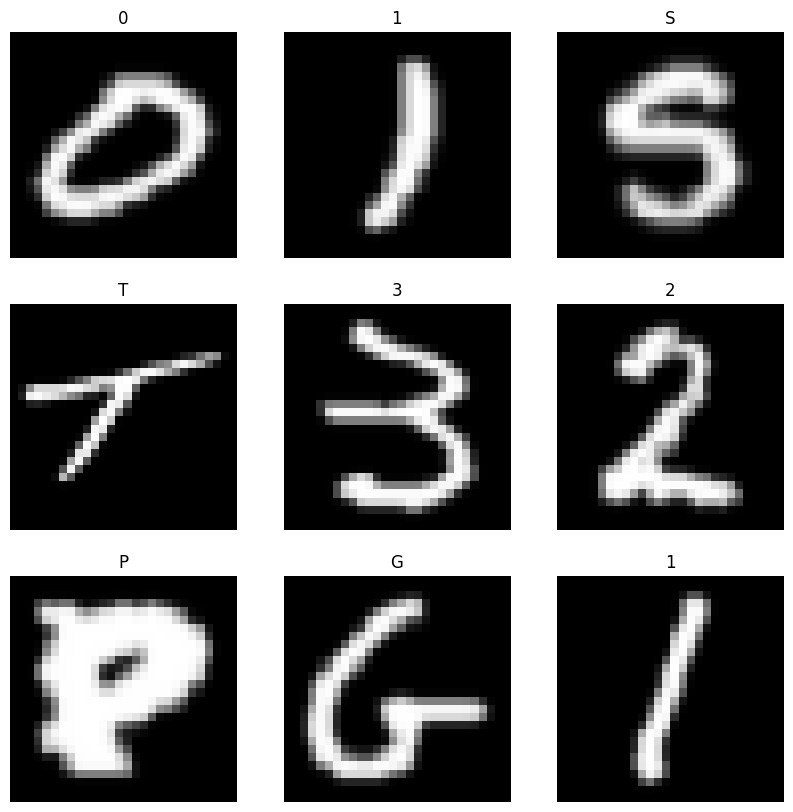

In [18]:
def show_batch(data_loader):
    images, labels = next(iter(data_loader))
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].permute(1, 2, 0) * 0.5 + 0.5)
        plt.title(dataset.classes[labels[i]])
        plt.axis('off')
    plt.show()

show_batch(train_loader)


CNN model architecture

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaseCNN(nn.Module):
    def __init__(self, num_classes=36):
        super(BaseCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.elu = nn.ELU()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = self.elu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# The above defined CNN model has total of 7 layers (including dropout) in the forward pass, including dropout.
# Input to the model is 28x28x3 (after transformation) and output is 36 neurons for 36 classes. Activation
# function used in hidden layers are elu and relu.


In [20]:
! pip install torchinfo


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Summary of your model

In [21]:

from torchinfo import summary

model = BaseCNN(num_classes=36)

summary(model, input_size=(32, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
BaseCNN                                  [32, 36]                  --
├─Conv2d: 1-1                            [32, 32, 28, 28]          896
├─Conv2d: 1-2                            [32, 64, 28, 28]          18,496
├─MaxPool2d: 1-3                         [32, 64, 14, 14]          --
├─Conv2d: 1-4                            [32, 128, 14, 14]         73,856
├─MaxPool2d: 1-5                         [32, 128, 7, 7]           --
├─Dropout: 1-6                           [32, 128, 7, 7]           --
├─Linear: 1-7                            [32, 128]                 802,944
├─ELU: 1-8                               [32, 128]                 --
├─Dropout: 1-9                           [32, 128]                 --
├─Linear: 1-10                           [32, 36]                  4,644
Total params: 900,836
Trainable params: 900,836
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 975.57
Input size (MB): 0.30
Fo

Train Model

In [22]:
import torch.optim as optim
seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

optimiser = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

criterion = nn.CrossEntropyLoss()

model.to(device)


epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)


    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")



Using device: cpu
Epoch [1/10] | Train Loss: 0.9787 | Train Acc: 70.73% | Val Acc: 87.59%
Epoch [2/10] | Train Loss: 0.4685 | Train Acc: 84.30% | Val Acc: 89.29%
Epoch [3/10] | Train Loss: 0.3855 | Train Acc: 86.74% | Val Acc: 89.97%
Epoch [4/10] | Train Loss: 0.3368 | Train Acc: 88.21% | Val Acc: 90.31%
Epoch [5/10] | Train Loss: 0.3079 | Train Acc: 88.97% | Val Acc: 90.74%
Epoch [6/10] | Train Loss: 0.2867 | Train Acc: 89.59% | Val Acc: 91.08%
Epoch [7/10] | Train Loss: 0.2699 | Train Acc: 90.22% | Val Acc: 91.50%
Epoch [8/10] | Train Loss: 0.2561 | Train Acc: 90.58% | Val Acc: 91.44%
Epoch [9/10] | Train Loss: 0.2427 | Train Acc: 90.83% | Val Acc: 91.56%
Epoch [10/10] | Train Loss: 0.2345 | Train Acc: 91.16% | Val Acc: 91.71%


In [25]:
pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 90.2 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

Early Stopping

In [35]:
import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score


# #seed = 42
# torch.manual_seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)

batch_size = 32
patience = 3



best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
best_epoch = 0


train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset , test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

criterion = nn.CrossEntropyLoss()

# Lists to store metrics for plotting
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

model_early = BaseCNN(num_classes=36).to(device)
optimiser = torch.optim.Adam(model_early.parameters(), lr=0.001)


train_time_start = time.time()
print(f"---------Training start time is here-----------------: {train_time_start}")
epochs = 10
for epoch in range(epochs):
    model_early.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model_early(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)


    model_early.eval()
    val_loss = 0.0
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_early(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss/len(val_loader)

    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}| Val Loss: {val_loss:.2f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_early.state_dict()
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print(f"Training time ends here: {time.time() - train_time_start} seconds")

model_early.load_state_dict(best_model_state)
print(f"Best model is saved at epoch {best_epoch+1}")

# model_early.eval()
# test_loss = 0.0
# test_correct, test_total = 0, 0
# with torch.no_grad():
#     for images, labels in test_loader:
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         test_loss += loss.item()
#         _, predicted = torch.max(outputs, 1)
#         test_correct += (predicted == labels).sum().item()
#         test_total += labels.size(0)

# test_loss /= len(test_loader)
# test_acc = 100 * test_correct / test_total

# print(f"Final Test Loss: {test_loss*100:.4f} | Test Accuracy: {test_acc:.2f}%")

#Commenting the above line of code since we need to calculate the precision, test accuracy, and hence storing it in
#list


all_preds = []
all_labels = []

model_early.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_early(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds) * 100
test_precision = precision_score(all_labels, all_preds, average='macro') * 100
test_recall = recall_score(all_labels, all_preds, average='macro') * 100
test_f1 = f1_score(all_labels, all_preds, average='macro') * 100

print(f"\n--- Test Metrics ---")
print(f"Accuracy : {test_accuracy:.2f}%")
print(f"Precision: {test_precision:.2f}%")
print(f"Recall   : {test_recall:.2f}%")
print(f"F1-score : {test_f1:.2f}%\n")

# Create test lists for plotting
test_acc_list = [test_accuracy] * len(train_acc_list)
test_loss_list = [0] * len(train_loss_list)

Using device: cpu
---------Training start time is here-----------------: 1762376631.931495
Epoch [1/10] | Train Loss: 0.5937 | Train Acc: 80.79% | Val Acc: 89.93| Val Loss: 0.28
Epoch [2/10] | Train Loss: 0.3455 | Train Acc: 87.66% | Val Acc: 90.58| Val Loss: 0.25
Epoch [3/10] | Train Loss: 0.3037 | Train Acc: 88.94% | Val Acc: 90.45| Val Loss: 0.26
Epoch [4/10] | Train Loss: 0.2806 | Train Acc: 89.64% | Val Acc: 91.04| Val Loss: 0.24
Epoch [5/10] | Train Loss: 0.2657 | Train Acc: 90.12% | Val Acc: 90.09| Val Loss: 0.25
Epoch [6/10] | Train Loss: 0.2549 | Train Acc: 90.24% | Val Acc: 91.42| Val Loss: 0.24
Epoch [7/10] | Train Loss: 0.2435 | Train Acc: 90.65% | Val Acc: 91.62| Val Loss: 0.24
Epoch [8/10] | Train Loss: 0.2337 | Train Acc: 90.97% | Val Acc: 91.60| Val Loss: 0.23
Epoch [9/10] | Train Loss: 0.2287 | Train Acc: 91.16% | Val Acc: 91.20| Val Loss: 0.24
Epoch [10/10] | Train Loss: 0.2233 | Train Acc: 91.30% | Val Acc: 90.80| Val Loss: 0.25
Training time ends here: 881.011831998

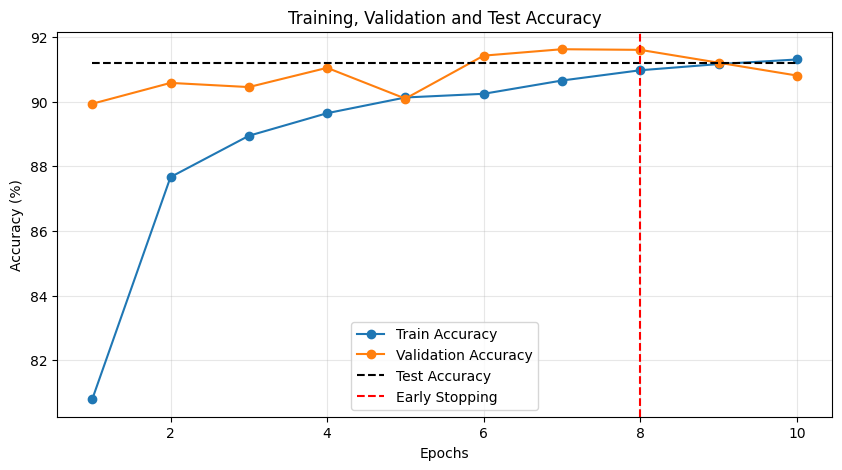

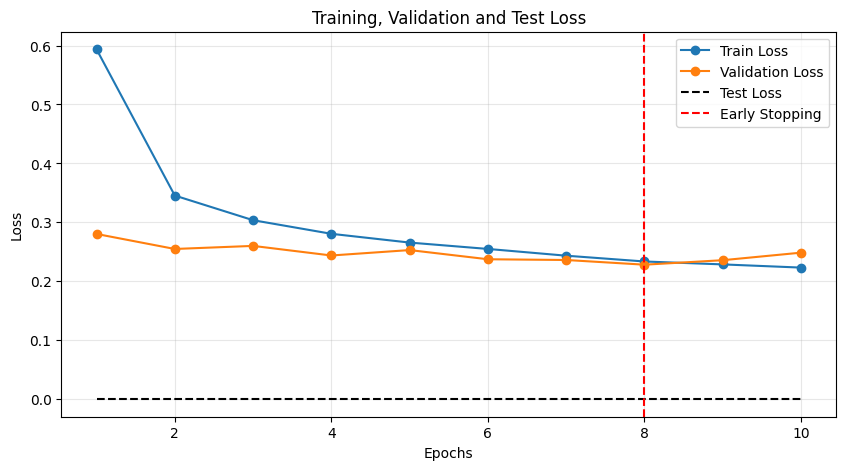

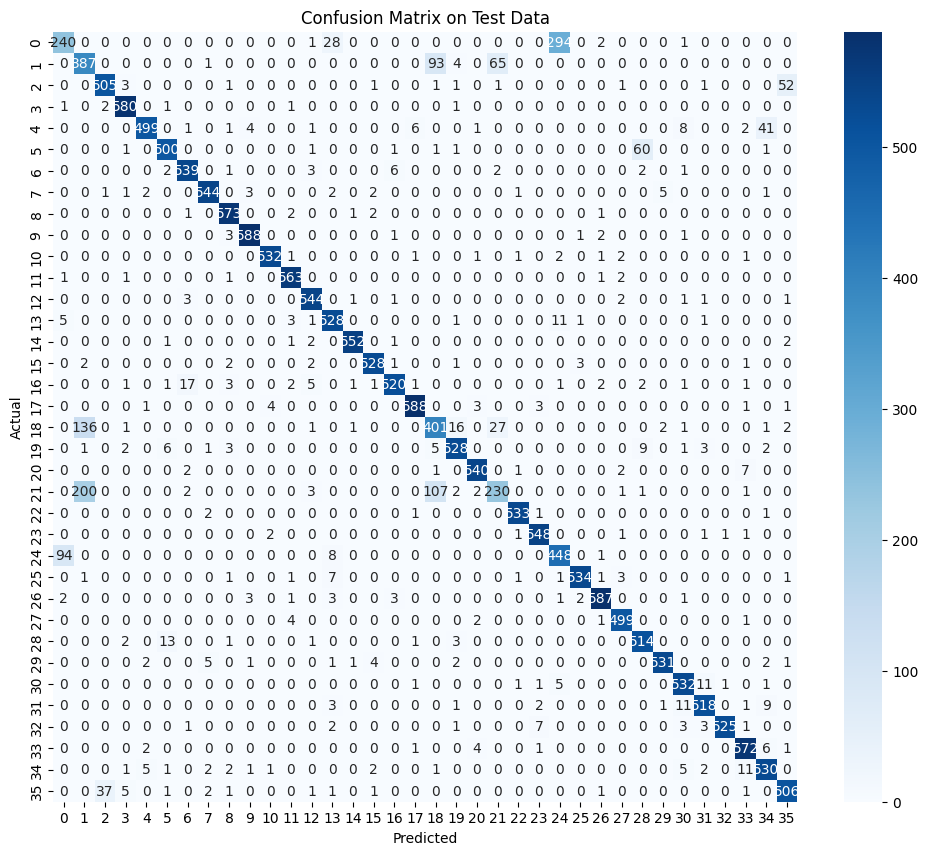

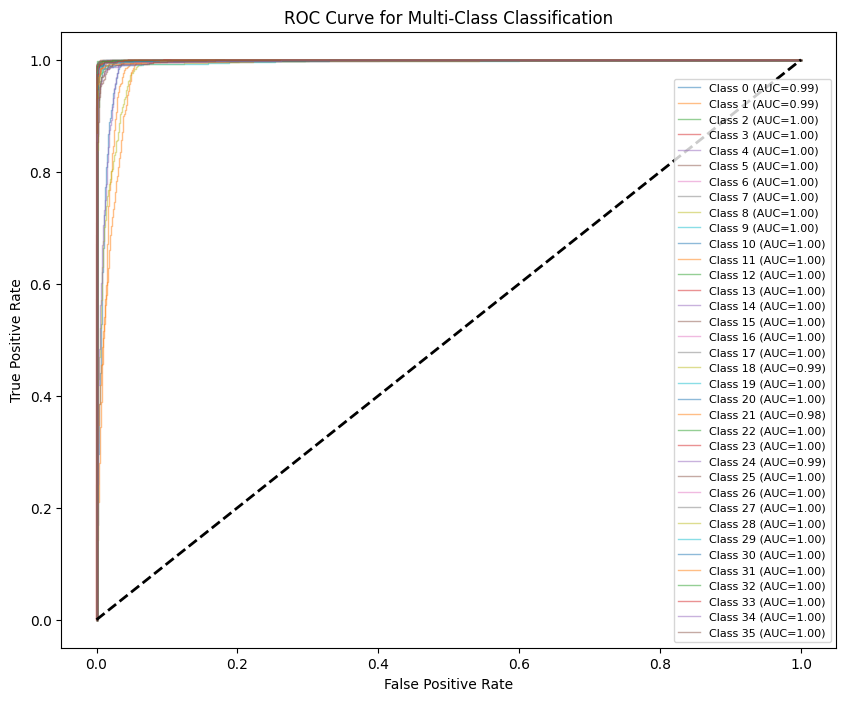

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


#Accuracy graph
plt.figure(figsize=(10,5))
plt.plot(range(1, len(train_acc_list)+1), train_acc_list, label='Train Accuracy', marker='o')
plt.plot(range(1, len(val_acc_list)+1), val_acc_list, label='Validation Accuracy', marker='o')
plt.plot(range(1, len(test_acc_list)+1), test_acc_list, label='Test Accuracy', linestyle='--', color='black')
plt.axvline(x=best_epoch+1, color='red', linestyle='--', label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training, Validation and Test Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Loss Plot
plt.figure(figsize=(10,5))
plt.plot(range(1, len(train_loss_list)+1), train_loss_list, label='Train Loss', marker='o')
plt.plot(range(1, len(val_loss_list)+1), val_loss_list, label='Validation Loss', marker='o')
plt.plot(range(1, len(test_loss_list)+1), test_loss_list, label='Test Loss', linestyle='--', color='black')
plt.axvline(x=best_epoch+1, color='red', linestyle='--', label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Test Data')
plt.show()

# ROC Curve (Multi-class)
num_classes = 36
y_test_bin = label_binarize(all_labels, classes=range(num_classes))


all_probs = []
model_early.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model_early(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

y_score = np.vstack(all_probs)

plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1, alpha=0.5, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='black', linestyle='--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right', fontsize=8)
plt.show()


K-FOLD

In [ ]:
import torch
from torch.utils.data import Subset
from sklearn.model_selection import KFold
import numpy as np

batch_size = 32
epochs = 3
k = 3  # Number of folds

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)





train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])


test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_train_accs, fold_val_accs = [], []
fold_train_losses, fold_val_losses = [], []
fold_test_accs, fold_test_precisions, fold_test_recalls, fold_test_f1s = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_dataset)):
    print(f"\n--- Fold {fold+1}/{k} ---")

    train_acc_list = []
    val_acc_list = []
    train_loss_list = []
    val_loss_list = []

    fold_train_subset = Subset(train_dataset, train_idx)
    fold_val_subset = Subset(train_dataset, val_idx)

    train_loader = DataLoader(fold_train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(fold_val_subset, batch_size=batch_size, shuffle=False)

    model_kfold = BaseCNN(num_classes=36).to(device)
    optimiser = torch.optim.Adam(model_kfold.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        # Training
        model_kfold.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimiser.zero_grad()
            outputs = model_kfold(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss = running_loss/len(train_loader)



        # Validation
        model_kfold.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model_kfold(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss/len(val_loader)

        val_acc_list.append(val_acc)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        train_loss_list.append(train_loss)       

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Training Loss : {train_loss:.2f}| Val Loss: {val_loss:.2f}| Val Acc: {val_acc:.2f}%")


    fold_train_accs.append(train_acc_list)
    fold_val_accs.append(val_acc_list)
    fold_train_losses.append(train_loss_list)
    fold_val_losses.append(val_loss_list)

    all_preds, all_labels = [], []
    test_loss_total = 0.0
    model_kfold.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_kfold(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            loss = criterion(outputs, labels)
            test_loss_total += loss.item()

    test_loss = test_loss_total / len(test_loader)


    test_accuracy = accuracy_score(all_labels, all_preds) * 100
    test_precision = precision_score(all_labels, all_preds, average='macro') * 100
    test_recall = recall_score(all_labels, all_preds, average='macro') * 100
    test_f1 = f1_score(all_labels, all_preds, average='macro') * 100

    fold_test_accs.append(test_accuracy)
    fold_test_precisions.append(test_precision)
    fold_test_recalls.append(test_recall)
    fold_test_f1s.append(test_f1)

# Extract last epoch accuracies for each fold
train_final_accs = [acc_list[-1] for acc_list in fold_train_accs]
val_final_accs = [acc_list[-1] for acc_list in fold_val_accs]


print(f"\nTrain Accuracy: {np.mean(train_final_accs):.2f}%")
print(f"Validation Accuracy: {np.mean(val_final_accs):.2f}%")
print(f"Test Accuracy: {np.mean(fold_test_accs):.2f}%")
print(f"Test Precision: {np.mean(fold_test_precisions):.2f}%")
print(f"Test Recall: {np.mean(fold_test_recalls):.2f}%")
print(f"Test F1-Score: {np.mean(fold_test_f1s):.2f}%")


Using device: cpu

--- Fold 1/3 ---
Epoch [1/3] | Train Acc: 77.51% | Training Loss : 0.70| Val Loss: 0.31| Val Acc: 88.78%
Epoch [2/3] | Train Acc: 86.56% | Training Loss : 0.39| Val Loss: 0.28| Val Acc: 89.68%
Epoch [3/3] | Train Acc: 87.96% | Training Loss : 0.33| Val Loss: 0.26| Val Acc: 90.49%

--- Fold 2/3 ---
Epoch [1/3] | Train Acc: 76.94% | Training Loss : 0.73| Val Loss: 0.33| Val Acc: 87.95%
Epoch [2/3] | Train Acc: 85.92% | Training Loss : 0.40| Val Loss: 0.30| Val Acc: 89.20%
Epoch [3/3] | Train Acc: 87.62% | Training Loss : 0.34| Val Loss: 0.26| Val Acc: 90.42%

--- Fold 3/3 ---
Epoch [1/3] | Train Acc: 77.45% | Training Loss : 0.72| Val Loss: 0.30| Val Acc: 88.93%
Epoch [2/3] | Train Acc: 86.62% | Training Loss : 0.38| Val Loss: 0.26| Val Acc: 90.05%
Epoch [3/3] | Train Acc: 87.94% | Training Loss : 0.33| Val Loss: 0.25| Val Acc: 90.54%
Train Accuracy: 87.84%
Validation Accuracy: 90.48%
Test Accuracy: 90.50%
Test Precision: 91.17%
Test Recall: 90.52%
Test F1-Score: 90.27

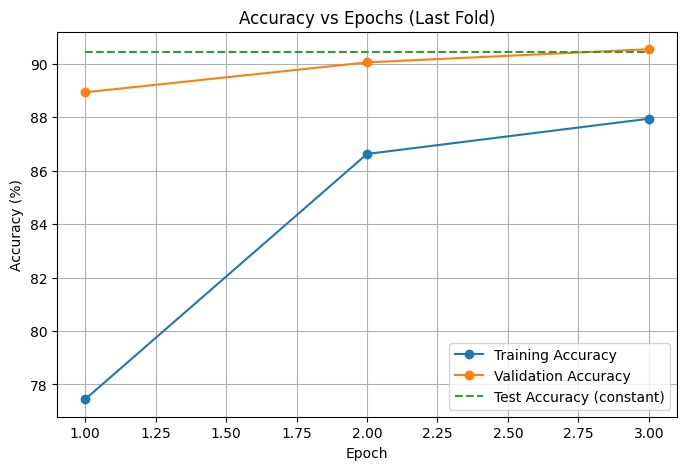

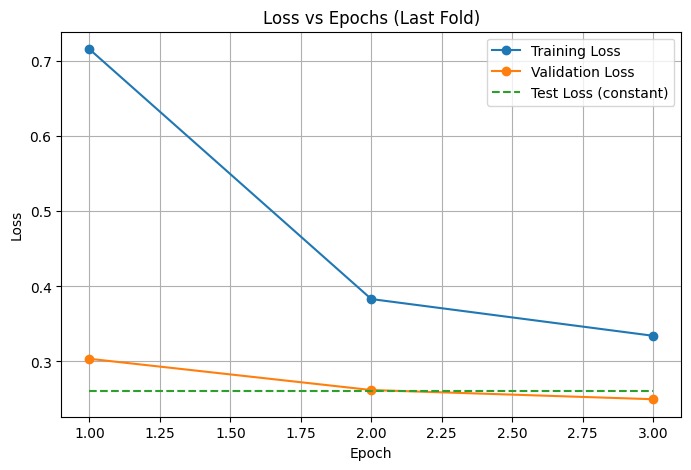

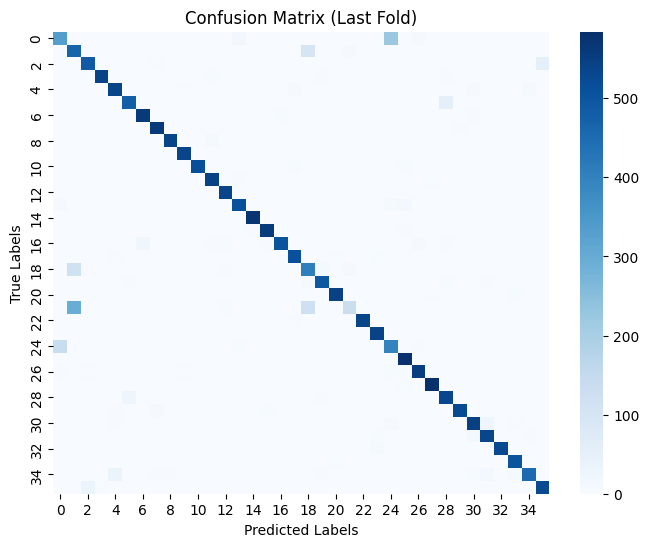

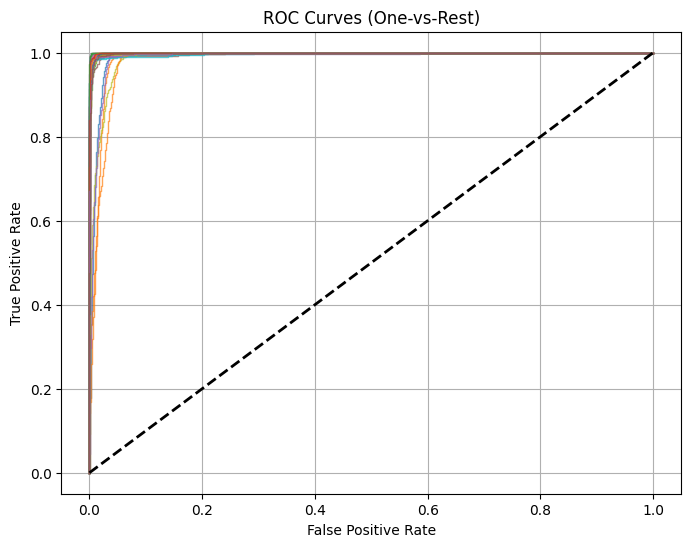

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 3: Plot accuracy and loss curves for the last fold ---
last_fold_val = k - 1  # index of last fold

train_acc = fold_train_accs[last_fold_val]
val_acc = fold_val_accs[last_fold_val]
train_loss = fold_train_losses[last_fold_val]
val_loss = fold_val_losses[last_fold_val]
test_acc = fold_test_accs[last_fold_val]

epochs_range = range(1, epochs + 1)

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.plot(epochs_range, [test_acc]*epochs, label='Test Accuracy (constant)', linestyle='--')
plt.title('Accuracy vs Epochs (Last Fold)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.plot(epochs_range, [test_loss]*epochs, label='Test Loss (constant)', linestyle='--')
plt.title('Loss vs Epochs (Last Fold)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()





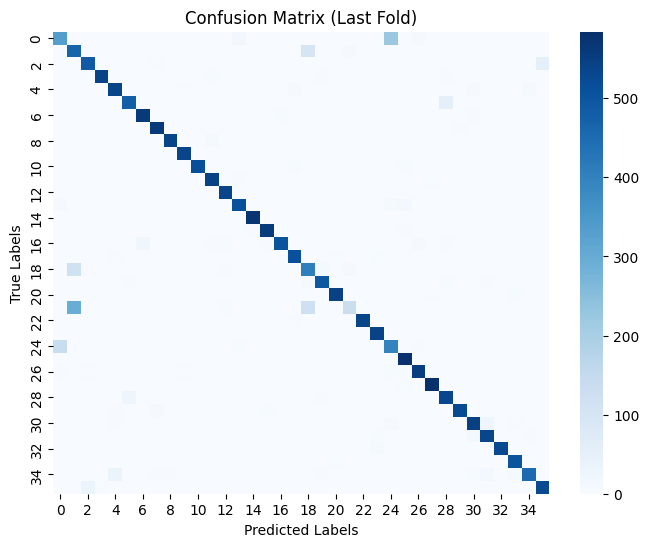

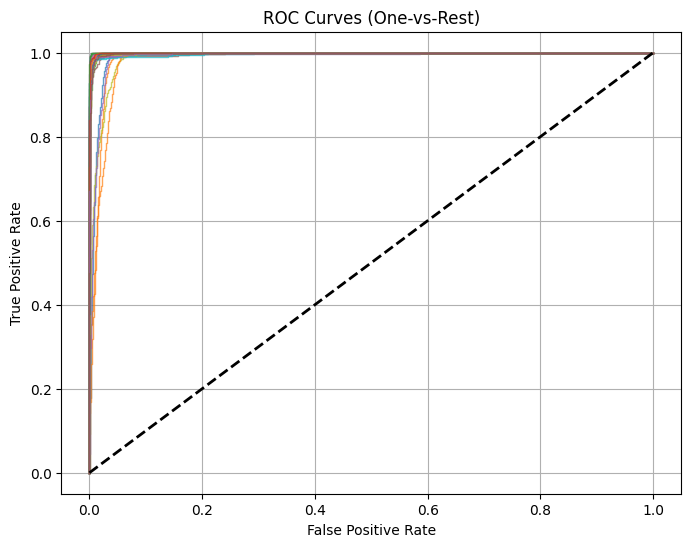

In [51]:
from sklearn.metrics import confusion_matrix

# --- Step 4: Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Last Fold)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

# --- Step 5: ROC Curve ---
num_classes = 36
# Convert labels to one-hot for multi-class ROC
y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# Get probabilities instead of predicted labels
model_kfold.eval()
all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_kfold(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

# Plot ROC for each class (or average)
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, lw=1, alpha=0.7)

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.title('ROC Curves (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

Learning Rate scheduler

In [59]:
import torch
from torch.utils.data import random_split, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

batch_size = 32
epochs = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Dataset split ---
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Model, optimizer, loss ---
model_learningrate = BaseCNN(num_classes=36).to(device)
optimiser = torch.optim.Adam(model_learningrate.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# --- Learning rate scheduler (HIGHLIGHT) ---
scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=1, gamma=0.5)  # LR reduced by 0.5 every epoch

train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(epochs):
    # --- Training ---
    model_learningrate.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model_learningrate(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # --- Validation ---
    model_learningrate.eval()
    val_loss = 0.0
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_learningrate(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    print(f"Current Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Train Loss: {train_loss:.2f} | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}")

    # --- Step the scheduler (HIGHLIGHT) ---
    scheduler.step()
    current_lr = optimiser.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr:.6f}")

# --- Testing ---
all_preds, all_labels = [], []
test_loss_total = 0.0
model_learningrate.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_learningrate(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        loss = criterion(outputs, labels)
        test_loss_total += loss.item()

test_loss = test_loss_total / len(test_loader)
test_accuracy = accuracy_score(all_labels, all_preds) * 100
test_precision = precision_score(all_labels, all_preds, average='macro') * 100
test_recall = recall_score(all_labels, all_preds, average='macro') * 100
test_f1 = f1_score(all_labels, all_preds, average='macro') * 100

print(f"\nTest Accuracy: {test_accuracy:.2f}%")
print(f"Test Precision: {test_precision:.2f}%")
print(f"Test Recall: {test_recall:.2f}%")
print(f"Test F1-Score: {test_f1:.2f}%")


Using device: cpu
Current Epoch 1/7 | Train Acc: 80.39% | Train Loss: 0.61 | Val Acc: 89.23% | Val Loss: 0.30
Current Learning Rate: 0.000500
Current Epoch 2/7 | Train Acc: 88.48% | Train Loss: 0.32 | Val Acc: 90.50% | Val Loss: 0.25
Current Learning Rate: 0.000250
Current Epoch 3/7 | Train Acc: 89.99% | Train Loss: 0.27 | Val Acc: 91.24% | Val Loss: 0.24
Current Learning Rate: 0.000125
Current Epoch 4/7 | Train Acc: 90.98% | Train Loss: 0.24 | Val Acc: 91.59% | Val Loss: 0.23
Current Learning Rate: 0.000063
Current Epoch 5/7 | Train Acc: 91.29% | Train Loss: 0.23 | Val Acc: 91.69% | Val Loss: 0.23
Current Learning Rate: 0.000031
Current Epoch 6/7 | Train Acc: 91.71% | Train Loss: 0.22 | Val Acc: 91.76% | Val Loss: 0.22
Current Learning Rate: 0.000016
Current Epoch 7/7 | Train Acc: 91.85% | Train Loss: 0.22 | Val Acc: 91.79% | Val Loss: 0.22
Current Learning Rate: 0.000008

Test Accuracy: 92.05%
Test Precision: 92.32%
Test Recall: 92.14%
Test F1-Score: 92.07%


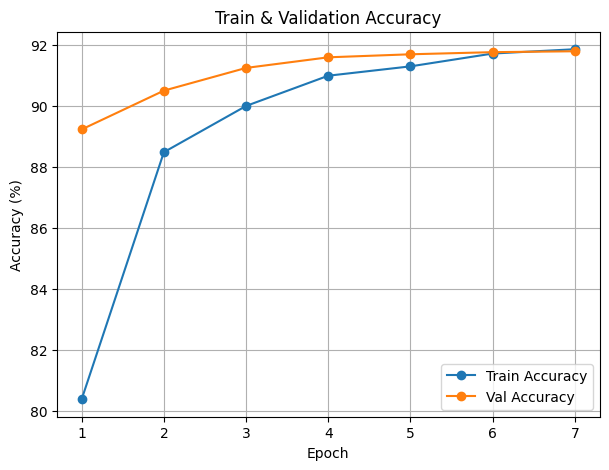

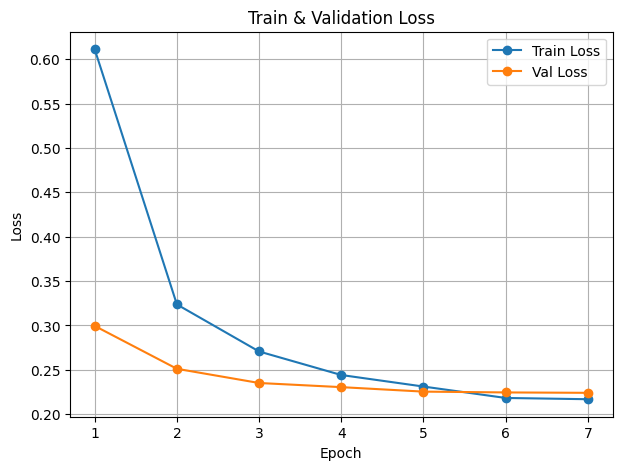

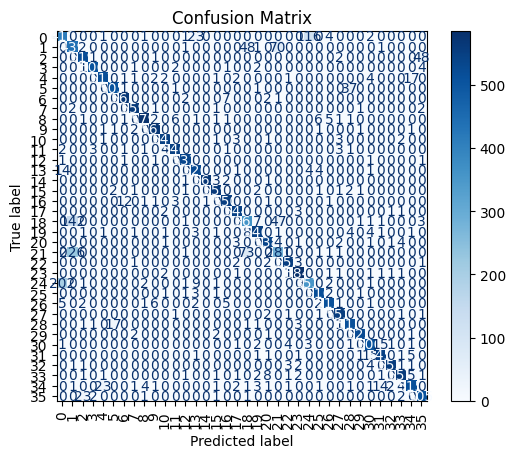

In [60]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

# --- Train & Validation Accuracy ---
plt.figure(figsize=(7,5))
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_list, label='Val Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Train & Validation Loss ---
plt.figure(figsize=(7,5))
plt.plot(epochs_range, train_loss_list, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss_list, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


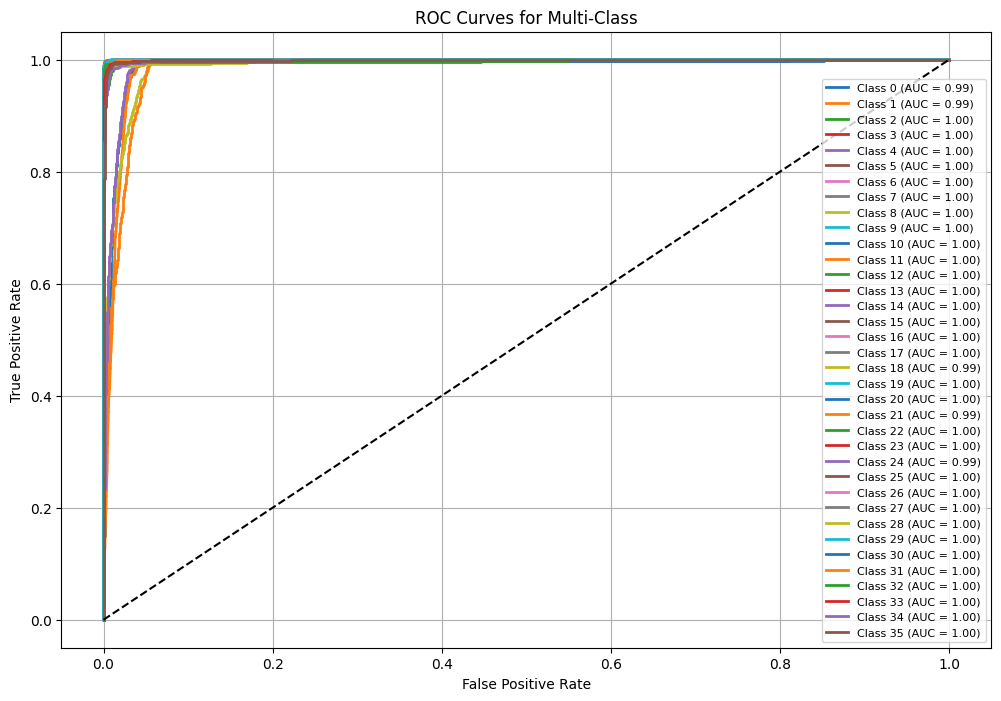

In [61]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels for multi-class ROC
num_classes = 36  # same as your model output
y_test_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# Get probabilities using softmax
model_learningrate.eval()
all_probs = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model_learningrate(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
all_probs = np.vstack(all_probs)

# Plot ROC for each class
plt.figure(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.show()


https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.label_binarize.html

https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Subset